In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [5]:
save_path = Path(r"C:\Users\Lindholm\Dropbox\BSc\report_figures")

### Model $H_S$

In [15]:
model_S_path = Path(r"E:\ae2d_experiments\5sec_gamma")
with np.load(model_S_path / "model_config.npz", allow_pickle=True) as data:
    # for key in data.files:
        # print(f"{key}: {data[key]}")
    latent_dim = data["latent_dim"].item()
    hidden_dim = data["hidden_dim"].item()
    input_channels = data["input_channels"].item()

In [16]:
with np.load(model_S_path / "archive" / "model_results.npz") as data:
    for key in data.files:
        model_S_train_losses = data["train_losses"]
        model_S_val_losses = data["val_losses"]
        model_S_epochs = data["epochs"]
        print(f"{key}: {data[key].shape}")

epochs: ()
train_losses: (12,)
val_losses: (12,)


### Model $H_U$

In [114]:
model_U_path = Path(r"E:\ae2d_experiments\5sec_delta")
with np.load(model_U_path / "model_results.npz") as data:
    for key in data.files:
        model_U_train_losses = data["train_losses"]
        model_U_val_losses = data["val_losses"]
        model_U_epochs = data["epochs"]
        print(f"{key}: {data[key].shape}")

epochs: ()
train_losses: (5,)
val_losses: (5,)


In [117]:
# with np.load(model_U_path / "exp_delta.npz", allow_pickle=True) as data:
#     for key in data.files:
#         print(f"{key}: {data[key]}")

### Model $H_{S2}$

In [65]:
model_S2_path1 = Path(r"E:\autoencoder_outputs_7750")
model_S2_train_losses = []
model_S2_val_losses = []
with np.load(model_S2_path1 / "train_stats.npz") as data:
    [model_S2_train_losses.append(v) for v in (data["train_losses"].tolist())]
    [model_S2_val_losses.append(v) for v in (data["val_losses"].tolist())]

model_S2_path2 = Path(r"E:\autoencoder_outputs_8241")
with np.load(model_S2_path2 / "train_stats.npz") as data:
    [model_S2_train_losses.append(v) for v in (data["train_losses"].tolist())]
    [model_S2_val_losses.append(v) for v in (data["val_losses"].tolist())]

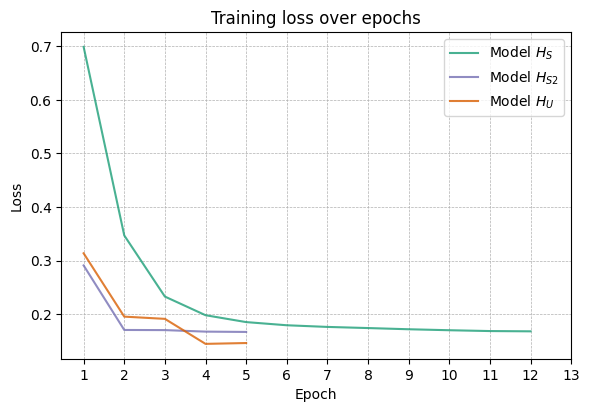

In [75]:
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.get_cmap("Dark2")
ax.plot(range(1, model_S_epochs), model_S_train_losses, label="Model $H_S$", color=cmap(0), alpha=0.8)
ax.plot(range(1, len(model_S2_train_losses)+1), model_S2_train_losses, label="Model $H_{S2}$", color=cmap(2), alpha=0.8)
ax.plot(range(1, model_U_epochs+1), model_U_train_losses, label="Model $H_U$", color=cmap(1), alpha=0.8)
# ax.plot(range(1, model_S_epochs), model_S_val_losses, label="Validation loss", color="mediumseagreen", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(range(1, max(model_S_epochs, model_U_epochs) + 1))
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.title("Training loss over epochs")
# plt.savefig(save_path / "training_validation_loss.png", dpi=300)
plt.show()

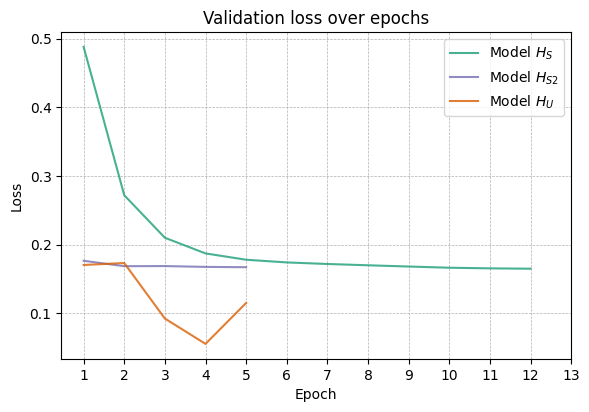

In [74]:
fig, ax = plt.subplots(figsize=(6, 4))
cmap = plt.get_cmap("Dark2")
ax.plot(range(1, model_S_epochs), model_S_val_losses, label="Model $H_S$", color=cmap(0), alpha=0.8)
ax.plot(range(1, len(model_S2_val_losses)+1), model_S2_val_losses, label="Model $H_{S2}$", color=cmap(2), alpha=0.8)
ax.plot(range(1, model_U_epochs+1), model_U_val_losses, label="Model $H_U$", color=cmap(1), alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(range(1, max(model_S_epochs, model_U_epochs) + 1))
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.title("Validation loss over epochs")
# plt.savefig(save_path / "training_validation_loss.png", dpi=300)
plt.show()

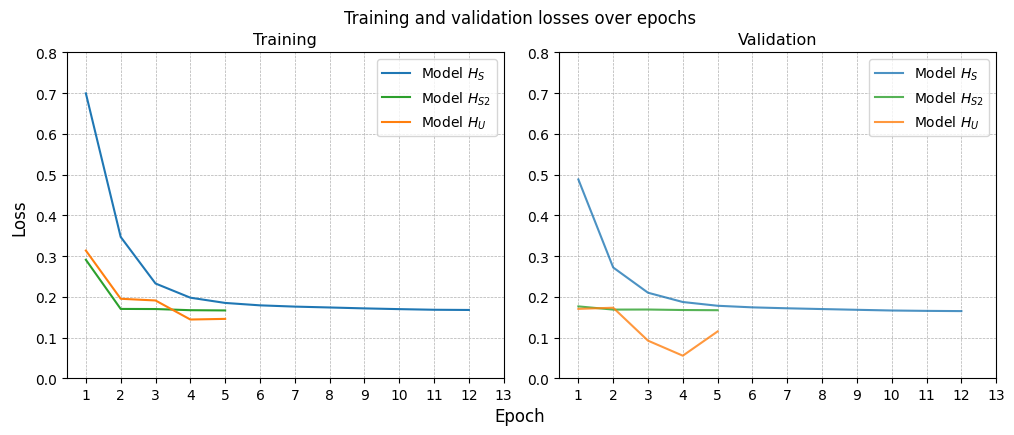

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
cmap = plt.get_cmap("tab10")
ax[0].plot(range(1, model_S_epochs), model_S_train_losses, label="Model $H_S$", color=cmap(0), alpha=1)
ax[0].plot(range(1, len(model_S2_train_losses)+1), model_S2_train_losses, label="Model $H_{S2}$", color=cmap(2), alpha=1)
ax[0].plot(range(1, model_U_epochs+1), model_U_train_losses, label="Model $H_U$", color=cmap(1), alpha=1)
ax[0].set_xticks(range(1, max(model_S_epochs, model_U_epochs) + 1))
ax[0].grid(which="both", linestyle="--", linewidth=0.5)
ax[0].legend()
ax[0].set_title("Training", size=11.5)
ax[0].set_ylim(0.0, 0.8)
ax[1].plot(range(1, model_S_epochs), model_S_val_losses, label="Model $H_S$", color=cmap(0), alpha=0.8)
ax[1].plot(range(1, len(model_S2_val_losses)+1), model_S2_val_losses, label="Model $H_{S2}$", color=cmap(2), alpha=0.8)
ax[1].plot(range(1, model_U_epochs+1), model_U_val_losses, label="Model $H_U$", color=cmap(1), alpha=0.8)
ax[1].set_xticks(range(1, max(model_S_epochs, model_U_epochs) + 1))
ax[1].grid(which="both", linestyle="--", linewidth=0.5)
ax[1].legend()
ax[1].set_title("Validation", size=11.5)
ax[1].set_ylim(0.0, 0.8)
plt.tight_layout()
fig.supylabel("Loss", x=-0.01)
fig.supxlabel("Epoch",y=-0.02)
plt.suptitle("Training and validation losses over epochs", y=1.02)
plt.savefig(save_path / "loss_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

In [108]:
(46+38)/5

16.8